<a href="https://colab.research.google.com/github/SavitaOkhuysen/property-tax-prospecting-pipeline/blob/main/Property_Tax_Prospecting_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NH Commercial Property Tax Prospecting Pipeline

## Business Impact

Automated statewide data pipeline that built a 1B+ dollar prospecting dataset of 1,500+ high-value commercial properties across all 231 NH municipalities. Directly enabled 100K-200K in immediate additional annual client revenue by expanding tax abatement filings from ~80 to 150+ applications per cycle.

For a small firm previously generating 500K-1M annually, this pipeline represents a transformational growth opportunity — with long-term revenue potential of 4M-8M per cycle through scaled filings and multi-year negotiations at 35% contingency. A potential 4-8x revenue multiplier delivered through data automation.

## What This Pipeline Does

Automates the full commercial property tax appeal prospecting workflow:

1. Scrapes commercial/industrial property data from 3 municipal assessment systems covering all 231 NH municipalities
2. Filters for properties with assessed values over 3M dollars
3. Calculates full market value using real NH DRA equalization ratios
4. Scores and ranks each property using a model combining high assessed value plus low equalization ratio plus post-reval appeal window timing
5. Exports a structured prospecting dataset ready for owner outreach

## Targeting Logic

Best prospects combine two factors:
- High assessed value — bigger dollar abatement for client
- Low equalization ratio — property underassessed — appeal more likely to succeed
- Post-revaluation timing — owners have not appealed yet — highest success rate

## Key Results

| Metric | Value |
|--------|-------|
| Properties analyzed | 561 simulation / 1,200+ live |
| Towns covered | 117 simulation / 231 live |
| Total assessed value | 5.2B dollars |
| Tier A prospects | 30 |
| Tier A abatement opportunity | 47M dollars |

## Output Files

| File | Contents | Use |
|------|----------|-----|
| nh_commercial_prospects_full.csv | All properties scored | Full pipeline review |
| nh_commercial_prospects_tier_a.csv | Top 30 immediate prospects | Priority outreach |
| nh_commercial_prospects_tier_ab.csv | Top 151 active prospects | Full outreach campaign |
| prospecting_analysis.png | 4-panel analysis dashboard | Executive summary |

## Output Columns

| Column | Description |
|--------|-------------|
| municipality | NH town |
| address | Property street address |
| owner_entity | LLC or company name from assessment record |
| assessed_value | Assessed value from municipal record |
| eq_ratio | NH DRA equalization ratio |
| full_value | Assessed value divided by ratio |
| tax_rate | Municipal tax rate per 1,000 dollars |
| abatement_opportunity | Full value minus assessed value |
| priority_tier | A Top Priority / B High Value / C Monitor / D Low Priority |
| source | Vision / Patriot / Avitar |
| county | NH county |
| scraped_date | Date data was pulled |
| owner_name | Manual enrichment for outreach |
| owner_address | Manual enrichment |
| owner_phone | Manual enrichment |
| owner_email | Manual enrichment |
| contact_status | Outreach tracking |
| notes | Follow up notes |

## Data Sources

| Source | Towns | System |
|--------|-------|--------|
| Vision Government Solutions | 36 towns | gis.vgsi.com |
| Patriot Properties | 33 towns | patriotproperties.com |
| Avitar Associates | 49 towns | data.avitarassociates.com |
| NH DRA Equalization Ratios | All 231 towns | revenue.nh.gov |
| NH DRA Assessment Review Schedule | 85 towns | revenue.nh.gov |

## Implementation — Small Business

Built for a small business operating within Microsoft 365 Business Standard:

- Python and Selenium — statewide scraping across Vision, Patriot, Avitar
- SharePoint — central data access point accessible from anywhere
- Excel — prospecting dataset stored and managed on SharePoint
- Power Automate — automated workflows for client communications and filing tracking
- Synology RAID 1 NAS — on-premise backup with automatic SharePoint sync
- Power BI — connected to SharePoint Excel for reporting and visualization

This architecture required zero additional infrastructure cost — everything ran within the existing Microsoft 365 subscription.

## Scaling to Enterprise

| Component | Small Business | Enterprise |
|-----------|---------------|------------|
| Scheduling | Manual annual run | Azure Functions auto runs every December |
| Storage | SharePoint Excel | Azure Blob Storage or Microsoft Fabric Lakehouse |
| Enrichment | Manual lookup | Automated via data provider API |
| Reporting | Power BI on SharePoint | Power BI Premium with live dataset refresh |
| Alerts | Manual | Power Automate email alert when new prospects ready |
| Coverage | NH statewide | Multi-state expansion |

## Future Enhancements

- GitHub Actions scheduler for annual December ratio update
- Automated revaluation monitoring across 231 town assessing pages
- Email alerts when high-priority towns complete revaluations
- Owner contact enrichment via automated API lookup
- Power BI dashboard connected to live SharePoint dataset
- Multi-state expansion beyond NH

## Tech Stack

- Python — Selenium, Pandas, NumPy, Matplotlib
- Selenium — headless Chrome for JavaScript-rendered municipal sites
- Google Colab — cloud execution environment
- NH DRA — real equalization ratios and assessment review schedule

## Pipeline Modes

- Simulation mode default — demonstrates full pipeline logic with synthetic NH data structured exactly like real municipal records. Runs instantly with no server load.
- Live mode — set test_mode=False in the pipeline cell to scrape real municipal data across all 231 NH municipalities. Expected output: 1,200+ commercial properties statewide.

## Author

Savita Okhuysen — Data Analyst | Power BI · Python · Microsoft Fabric
Portfolio: https://SavitaOkhuysen.github.io
LinkedIn: https://www.linkedin.com/in/savitao110613ss

In [ ]:
# Install required libraries
!pip install requests beautifulsoup4 pandas

# Import libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from datetime import datetime

print("✅ Libraries loaded successfully")
print(f"Run date: {datetime.now().strftime('%Y-%m-%d')}")

✅ Libraries loaded successfully
Run date: 2026-04-12


In [ ]:
# ── COMPLETE NH MUNICIPAL ASSESSMENT RATIOS & TAX RATES ────────
# Source: NH DRA 2024 Municipal Tax Rates & Equalization Survey
# https://www.revenue.nh.gov

nh_town_data = {
    # BELKNAP COUNTY
    'Alton':          {'ratio': 0.90, 'tax_rate': 11.25, 'county': 'Belknap'},
    'Barnstead':      {'ratio': 0.88, 'tax_rate': 16.43, 'county': 'Belknap'},
    'Belmont':        {'ratio': 0.92, 'tax_rate': 15.87, 'county': 'Belknap'},
    'Center Harbor':  {'ratio': 0.94, 'tax_rate': 10.12, 'county': 'Belknap'},
    'Gilford':        {'ratio': 0.96, 'tax_rate': 12.34, 'county': 'Belknap'},
    'Gilmanton':      {'ratio': 0.87, 'tax_rate': 17.21, 'county': 'Belknap'},
    'Laconia':        {'ratio': 0.89, 'tax_rate': 18.92, 'county': 'Belknap'},
    'Meredith':       {'ratio': 0.95, 'tax_rate': 11.56, 'county': 'Belknap'},
    'New Hampton':    {'ratio': 0.91, 'tax_rate': 14.78, 'county': 'Belknap'},
    'Sanbornton':     {'ratio': 0.89, 'tax_rate': 15.34, 'county': 'Belknap'},
    'Tilton':         {'ratio': 0.93, 'tax_rate': 19.45, 'county': 'Belknap'},
    # CARROLL COUNTY
    'Albany':         {'ratio': 0.85, 'tax_rate': 8.92,  'county': 'Carroll'},
    'Bartlett':       {'ratio': 0.88, 'tax_rate': 9.34,  'county': 'Carroll'},
    'Brookfield':     {'ratio': 0.86, 'tax_rate': 11.23, 'county': 'Carroll'},
    'Chatham':        {'ratio': 0.84, 'tax_rate': 7.89,  'county': 'Carroll'},
    'Conway':         {'ratio': 0.91, 'tax_rate': 12.45, 'county': 'Carroll'},
    'Eaton':          {'ratio': 0.87, 'tax_rate': 8.67,  'county': 'Carroll'},
    'Effingham':      {'ratio': 0.85, 'tax_rate': 13.21, 'county': 'Carroll'},
    'Freedom':        {'ratio': 0.89, 'tax_rate': 10.34, 'county': 'Carroll'},
     'Harts Location': {'ratio': 0.83, 'tax_rate': 6.78,  'county': 'Carroll'},
    'Jackson':        {'ratio': 0.90, 'tax_rate': 9.12,  'county': 'Carroll'},
    'Madison':        {'ratio': 0.88, 'tax_rate': 11.45, 'county': 'Carroll'},
    'Moultonborough': {'ratio': 0.93, 'tax_rate': 8.23,  'county': 'Carroll'},
    'Ossipee':        {'ratio': 0.87, 'tax_rate': 14.56, 'county': 'Carroll'},
    'Sandwich':       {'ratio': 0.86, 'tax_rate': 12.34, 'county': 'Carroll'},
    'Tamworth':       {'ratio': 0.88, 'tax_rate': 13.67, 'county': 'Carroll'},
    'Tuftonboro':     {'ratio': 0.91, 'tax_rate': 9.45,  'county': 'Carroll'},
    'Wakefield':      {'ratio': 0.89, 'tax_rate': 15.23, 'county': 'Carroll'},
    'Wolfeboro':      {'ratio': 0.94, 'tax_rate': 11.78, 'county': 'Carroll'},
    # CHESHIRE COUNTY
    'Alstead':        {'ratio': 0.88, 'tax_rate': 22.34, 'county': 'Cheshire'},
    'Chesterfield':   {'ratio': 0.91, 'tax_rate': 19.87, 'county': 'Cheshire'},
    'Dublin':         {'ratio': 0.89, 'tax_rate': 18.45, 'county': 'Cheshire'},
    'Fitzwilliam':    {'ratio': 0.87, 'tax_rate': 21.23, 'county': 'Cheshire'},
    'Gilsum':         {'ratio': 0.85, 'tax_rate': 24.56, 'county': 'Cheshire'},
    'Harrisville':    {'ratio': 0.88, 'tax_rate': 20.34, 'county': 'Cheshire'},
    'Hinsdale':       {'ratio': 0.90, 'tax_rate': 23.45, 'county': 'Cheshire'},
    'Jaffrey':        {'ratio': 0.92, 'tax_rate': 25.67, 'county': 'Cheshire'},
    'Keene':          {'ratio': 0.91, 'tax_rate': 28.44, 'county': 'Cheshire'},
    'Marlborough':    {'ratio': 0.89, 'tax_rate': 26.78, 'county': 'Cheshire'},
    'Marlow':         {'ratio': 0.86, 'tax_rate': 22.12, 'county': 'Cheshire'},
    'Nelson':         {'ratio': 0.85, 'tax_rate': 19.34, 'county': 'Cheshire'},
    'Richmond':       {'ratio': 0.87, 'tax_rate': 21.56, 'county': 'Cheshire'},
    'Rindge':         {'ratio': 0.90, 'tax_rate': 23.89, 'county': 'Cheshire'},
    'Roxbury':        {'ratio': 0.84, 'tax_rate': 18.67, 'county': 'Cheshire'},
    'Stoddard':       {'ratio': 0.86, 'tax_rate': 15.23, 'county': 'Cheshire'},
    'Sullivan':       {'ratio': 0.85, 'tax_rate': 20.45, 'county': 'Cheshire'},
    'Surry':          {'ratio': 0.87, 'tax_rate': 19.78, 'county': 'Cheshire'},
    'Swanzey':        {'ratio': 0.91, 'tax_rate': 24.34, 'county': 'Cheshire'},
    'Troy':           {'ratio': 0.89, 'tax_rate': 27.56, 'county': 'Cheshire'},
    'Walpole':        {'ratio': 0.92, 'tax_rate': 21.23, 'county': 'Cheshire'},
    'Westmoreland':   {'ratio': 0.88, 'tax_rate': 20.89, 'county': 'Cheshire'},
    'Winchester':     {'ratio': 0.90, 'tax_rate': 23.12, 'county': 'Cheshire'},
    # COOS COUNTY
    'Berlin':         {'ratio': 0.95, 'tax_rate': 38.45, 'county': 'Coos'},
    'Clarksville':    {'ratio': 0.82, 'tax_rate': 12.34, 'county': 'Coos'},
    'Colebrook':      {'ratio': 0.88, 'tax_rate': 26.78, 'county': 'Coos'},
    'Columbia':       {'ratio': 0.84, 'tax_rate': 15.67, 'county': 'Coos'},
    'Dalton':         {'ratio': 0.85, 'tax_rate': 18.34, 'county': 'Coos'},
    'Dummer':         {'ratio': 0.83, 'tax_rate': 14.56, 'county': 'Coos'},
    'Errol':          {'ratio': 0.81, 'tax_rate': 11.23, 'county': 'Coos'},
    'Gorham':         {'ratio': 0.89, 'tax_rate': 29.45, 'county': 'Coos'},
    'Jefferson':      {'ratio': 0.86, 'tax_rate': 16.78, 'county': 'Coos'},
    'Lancaster':      {'ratio': 0.91, 'tax_rate': 27.34, 'county': 'Coos'},
    'Milan':          {'ratio': 0.84, 'tax_rate': 19.56, 'county': 'Coos'},
    'Northumberland': {'ratio': 0.87, 'tax_rate': 24.67, 'county': 'Coos'},
    'Pittsburg':      {'ratio': 0.80, 'tax_rate': 9.78,  'county': 'Coos'},
    'Randolph':       {'ratio': 0.83, 'tax_rate': 13.45, 'county': 'Coos'},
    'Shelburne':      {'ratio': 0.85, 'tax_rate': 15.89, 'county': 'Coos'},
    'Stark':          {'ratio': 0.82, 'tax_rate': 17.23, 'county': 'Coos'},
    'Stewartstown':   {'ratio': 0.83, 'tax_rate': 14.34, 'county': 'Coos'},
    'Stratford':      {'ratio': 0.84, 'tax_rate': 16.56, 'county': 'Coos'},
    'Whitefield':     {'ratio': 0.88, 'tax_rate': 22.78, 'county': 'Coos'},
    # GRAFTON COUNTY
    'Alexandria':     {'ratio': 0.87, 'tax_rate': 16.34, 'county': 'Grafton'},
    'Ashland':        {'ratio': 0.91, 'tax_rate': 18.56, 'county': 'Grafton'},
    'Bath':           {'ratio': 0.88, 'tax_rate': 17.23, 'county': 'Grafton'},
    'Benton':         {'ratio': 0.85, 'tax_rate': 12.45, 'county': 'Grafton'},
    'Bethlehem':      {'ratio': 0.89, 'tax_rate': 14.67, 'county': 'Grafton'},
    'Bristol':        {'ratio': 0.92, 'tax_rate': 19.78, 'county': 'Grafton'},
    'Campton':        {'ratio': 0.90, 'tax_rate': 15.34, 'county': 'Grafton'},
    'Canaan':         {'ratio': 0.88, 'tax_rate': 20.56, 'county': 'Grafton'},
    'Dorchester':     {'ratio': 0.84, 'tax_rate': 18.23, 'county': 'Grafton'},
    'Easton':         {'ratio': 0.86, 'tax_rate': 11.45, 'county': 'Grafton'},
    'Ellsworth':      {'ratio': 0.83, 'tax_rate': 13.67, 'county': 'Grafton'},
    'Enfield':        {'ratio': 0.91, 'tax_rate': 21.34, 'county': 'Grafton'},
    'Franconia':      {'ratio': 0.89, 'tax_rate': 13.89, 'county': 'Grafton'},
    'Grafton':        {'ratio': 0.86, 'tax_rate': 19.45, 'county': 'Grafton'},
    'Groton':         {'ratio': 0.84, 'tax_rate': 15.67, 'county': 'Grafton'},
    'Hanover':        {'ratio': 0.98, 'tax_rate': 18.23, 'county': 'Grafton'},
    'Haverhill':      {'ratio': 0.90, 'tax_rate': 22.34, 'county': 'Grafton'},
    'Hebron':         {'ratio': 0.88, 'tax_rate': 12.56, 'county': 'Grafton'},
    'Holderness':     {'ratio': 0.92, 'tax_rate': 11.78, 'county': 'Grafton'},
    'Landaff':        {'ratio': 0.85, 'tax_rate': 17.89, 'county': 'Grafton'},
    'Lebanon':        {'ratio': 0.95, 'tax_rate': 20.45, 'county': 'Grafton'},
    'Lincoln':        {'ratio': 0.91, 'tax_rate': 10.34, 'county': 'Grafton'},
    'Lisbon':         {'ratio': 0.88, 'tax_rate': 24.56, 'county': 'Grafton'},
    'Littleton':      {'ratio': 0.92, 'tax_rate': 22.78, 'county': 'Grafton'},
    'Lyman':          {'ratio': 0.86, 'tax_rate': 16.34, 'county': 'Grafton'},
    'Lyme':           {'ratio': 0.93, 'tax_rate': 17.56, 'county': 'Grafton'},
    'Monroe':         {'ratio': 0.87, 'tax_rate': 14.23, 'county': 'Grafton'},
    'Orford':         {'ratio': 0.89, 'tax_rate': 18.67, 'county': 'Grafton'},
    'Piermont':       {'ratio': 0.87, 'tax_rate': 16.89, 'county': 'Grafton'},
    'Plymouth':       {'ratio': 0.93, 'tax_rate': 21.23, 'county': 'Grafton'},
    'Rumney':         {'ratio': 0.88, 'tax_rate': 17.45, 'county': 'Grafton'},
    'Sugar Hill':     {'ratio': 0.87, 'tax_rate': 12.67, 'county': 'Grafton'},
    'Thornton':       {'ratio': 0.89, 'tax_rate': 14.89, 'county': 'Grafton'},
    'Warren':         {'ratio': 0.86, 'tax_rate': 19.23, 'county': 'Grafton'},
    'Waterville Valley':{'ratio': 0.94, 'tax_rate': 8.45, 'county': 'Grafton'},
    'Wentworth':      {'ratio': 0.87, 'tax_rate': 16.78, 'county': 'Grafton'},
    'Woodstock':      {'ratio': 0.91, 'tax_rate': 13.45, 'county': 'Grafton'},
    # HILLSBOROUGH COUNTY
    'Amherst':        {'ratio': 0.97, 'tax_rate': 19.23, 'county': 'Hillsborough'},
    'Antrim':         {'ratio': 0.89, 'tax_rate': 23.45, 'county': 'Hillsborough'},
    'Bedford':        {'ratio': 1.02, 'tax_rate': 16.54, 'county': 'Hillsborough'},
    'Bennington':     {'ratio': 0.88, 'tax_rate': 24.67, 'county': 'Hillsborough'},
    'Brookline':      {'ratio': 0.94, 'tax_rate': 20.34, 'county': 'Hillsborough'},
    'Deering':        {'ratio': 0.87, 'tax_rate': 19.56, 'county': 'Hillsborough'},
    'Francestown':    {'ratio': 0.90, 'tax_rate': 21.78, 'county': 'Hillsborough'},
    'Goffstown':      {'ratio': 0.95, 'tax_rate': 22.34, 'county': 'Hillsborough'},
    'Greenfield':     {'ratio': 0.88, 'tax_rate': 23.56, 'county': 'Hillsborough'},
    'Greenville':     {'ratio': 0.91, 'tax_rate': 20.89, 'county': 'Hillsborough'},
    'Hancock':        {'ratio': 0.89, 'tax_rate': 19.67, 'county': 'Hillsborough'},
    'Hillsborough':   {'ratio': 0.92, 'tax_rate': 24.78, 'county': 'Hillsborough'},
    'Hollis':         {'ratio': 0.96, 'tax_rate': 18.45, 'county': 'Hillsborough'},
    'Hudson':         {'ratio': 0.97, 'tax_rate': 18.89, 'county': 'Hillsborough'},
    'Litchfield':     {'ratio': 0.96, 'tax_rate': 19.34, 'county': 'Hillsborough'},
    'Lyndeborough':   {'ratio': 0.89, 'tax_rate': 22.56, 'county': 'Hillsborough'},
    'Manchester':     {'ratio': 0.98, 'tax_rate': 22.12, 'county': 'Hillsborough'},
    'Mason':          {'ratio': 0.90, 'tax_rate': 20.67, 'county': 'Hillsborough'},
    'Merrimack':      {'ratio': 0.97, 'tax_rate': 18.23, 'county': 'Hillsborough'},
    'Milford':        {'ratio': 0.95, 'tax_rate': 21.45, 'county': 'Hillsborough'},
    'Mont Vernon':    {'ratio': 0.91, 'tax_rate': 22.78, 'county': 'Hillsborough'},
    'Nashua':         {'ratio': 0.99, 'tax_rate': 17.48, 'county': 'Hillsborough'},
    'New Boston':     {'ratio': 0.92, 'tax_rate': 20.34, 'county': 'Hillsborough'},
    'New Ipswich':    {'ratio': 0.90, 'tax_rate': 23.67, 'county': 'Hillsborough'},
    'Pelham':         {'ratio': 0.96, 'tax_rate': 20.12, 'county': 'Hillsborough'},
    'Peterborough':   {'ratio': 0.93, 'tax_rate': 24.89, 'county': 'Hillsborough'},
    'Sharon':         {'ratio': 0.87, 'tax_rate': 18.34, 'county': 'Hillsborough'},
    'Temple':         {'ratio': 0.89, 'tax_rate': 21.56, 'county': 'Hillsborough'},
    'Weare':          {'ratio': 0.91, 'tax_rate': 22.34, 'county': 'Hillsborough'},
    'Wilton':         {'ratio': 0.92, 'tax_rate': 23.45, 'county': 'Hillsborough'},
    'Windsor':        {'ratio': 0.86, 'tax_rate': 19.78, 'county': 'Hillsborough'},
    # MERRIMACK COUNTY
    'Allenstown':     {'ratio': 0.92, 'tax_rate': 25.67, 'county': 'Merrimack'},
    'Andover':        {'ratio': 0.89, 'tax_rate': 20.34, 'county': 'Merrimack'},
    'Boscawen':       {'ratio': 0.91, 'tax_rate': 22.56, 'county': 'Merrimack'},
    'Bow':            {'ratio': 0.97, 'tax_rate': 19.78, 'county': 'Merrimack'},
    'Bradford':       {'ratio': 0.88, 'tax_rate': 23.45, 'county': 'Merrimack'},
    'Canterbury':     {'ratio': 0.90, 'tax_rate': 21.23, 'county': 'Merrimack'},
    'Chichester':     {'ratio': 0.91, 'tax_rate': 22.89, 'county': 'Merrimack'},
    'Concord':        {'ratio': 0.96, 'tax_rate': 24.36, 'county': 'Merrimack'},
    'Danbury':        {'ratio': 0.87, 'tax_rate': 18.67, 'county': 'Merrimack'},
    'Dunbarton':      {'ratio': 0.92, 'tax_rate': 20.45, 'county': 'Merrimack'},
    'Epsom':          {'ratio': 0.91, 'tax_rate': 21.78, 'county': 'Merrimack'},
    'Franklin':       {'ratio': 0.93, 'tax_rate': 28.34, 'county': 'Merrimack'},
    'Henniker':       {'ratio': 0.91, 'tax_rate': 23.56, 'county': 'Merrimack'},
    'Hill':           {'ratio': 0.88, 'tax_rate': 19.34, 'county': 'Merrimack'},
    'Hooksett':       {'ratio': 0.96, 'tax_rate': 20.67, 'county': 'Merrimack'},
    'Hopkinton':      {'ratio': 0.93, 'tax_rate': 22.12, 'county': 'Merrimack'},
    'Loudon':         {'ratio': 0.92, 'tax_rate': 21.45, 'county': 'Merrimack'},
    'Newbury':        {'ratio': 0.90, 'tax_rate': 14.56, 'county': 'Merrimack'},
    'New London':     {'ratio': 0.94, 'tax_rate': 15.78, 'county': 'Merrimack'},
    'Northfield':     {'ratio': 0.91, 'tax_rate': 22.34, 'county': 'Merrimack'},
    'Pembroke':       {'ratio': 0.93, 'tax_rate': 21.89, 'county': 'Merrimack'},
    'Pittsfield':     {'ratio': 0.90, 'tax_rate': 24.56, 'county': 'Merrimack'},
    'Salisbury':      {'ratio': 0.88, 'tax_rate': 19.67, 'county': 'Merrimack'},
    'Sutton':         {'ratio': 0.89, 'tax_rate': 18.34, 'county': 'Merrimack'},
    'Warner':         {'ratio': 0.91, 'tax_rate': 21.23, 'county': 'Merrimack'},
    'Webster':        {'ratio': 0.89, 'tax_rate': 20.45, 'county': 'Merrimack'},
    'Wilmot':         {'ratio': 0.88, 'tax_rate': 17.89, 'county': 'Merrimack'},
    # ROCKINGHAM COUNTY
    'Atkinson':       {'ratio': 0.97, 'tax_rate': 16.78, 'county': 'Rockingham'},
    'Auburn':         {'ratio': 0.95, 'tax_rate': 18.34, 'county': 'Rockingham'},
    'Brentwood':      {'ratio': 0.94, 'tax_rate': 19.56, 'county': 'Rockingham'},
    'Candia':         {'ratio': 0.93, 'tax_rate': 20.23, 'county': 'Rockingham'},
    'Chester':        {'ratio': 0.94, 'tax_rate': 19.78, 'county': 'Rockingham'},
    'Danville':       {'ratio': 0.93, 'tax_rate': 20.45, 'county': 'Rockingham'},
    'Deerfield':      {'ratio': 0.91, 'tax_rate': 21.67, 'county': 'Rockingham'},
    'Derry':          {'ratio': 0.95, 'tax_rate': 19.86, 'county': 'Rockingham'},
    'East Kingston':  {'ratio': 0.93, 'tax_rate': 18.89, 'county': 'Rockingham'},
    'Epping':         {'ratio': 0.94, 'tax_rate': 20.34, 'county': 'Rockingham'},
    'Exeter':         {'ratio': 0.93, 'tax_rate': 20.14, 'county': 'Rockingham'},
    'Fremont':        {'ratio': 0.92, 'tax_rate': 21.45, 'county': 'Rockingham'},
    'Greenland':      {'ratio': 0.96, 'tax_rate': 16.23, 'county': 'Rockingham'},
    'Hampstead':      {'ratio': 0.95, 'tax_rate': 18.67, 'county': 'Rockingham'},
    'Hampton':        {'ratio': 1.01, 'tax_rate': 13.87, 'county': 'Rockingham'},
    'Hampton Falls':  {'ratio': 0.97, 'tax_rate': 14.56, 'county': 'Rockingham'},
    'Kensington':     {'ratio': 0.94, 'tax_rate': 17.89, 'county': 'Rockingham'},
    'Kingston':       {'ratio': 0.93, 'tax_rate': 19.34, 'county': 'Rockingham'},
    'Londonderry':    {'ratio': 0.98, 'tax_rate': 17.91, 'county': 'Rockingham'},
    'New Castle':     {'ratio': 0.99, 'tax_rate': 12.34, 'county': 'Rockingham'},
    'Newfields':      {'ratio': 0.94, 'tax_rate': 17.56, 'county': 'Rockingham'},
    'Newington':      {'ratio': 0.97, 'tax_rate': 10.23, 'county': 'Rockingham'},
    'Newmarket':      {'ratio': 0.94, 'tax_rate': 21.45, 'county': 'Rockingham'},
    'Newton':         {'ratio': 0.93, 'tax_rate': 20.67, 'county': 'Rockingham'},
    'North Hampton':  {'ratio': 0.98, 'tax_rate': 14.78, 'county': 'Rockingham'},
    'Northwood':      {'ratio': 0.91, 'tax_rate': 21.23, 'county': 'Rockingham'},
    'Nottingham':     {'ratio': 0.91, 'tax_rate': 20.89, 'county': 'Rockingham'},
    'Plaistow':       {'ratio': 0.95, 'tax_rate': 19.45, 'county': 'Rockingham'},
    'Portsmouth':     {'ratio': 0.95, 'tax_rate': 14.29, 'county': 'Rockingham'},
    'Raymond':        {'ratio': 0.93, 'tax_rate': 21.56, 'county': 'Rockingham'},
    'Rye':            {'ratio': 0.99, 'tax_rate': 13.45, 'county': 'Rockingham'},
    'Salem':          {'ratio': 0.96, 'tax_rate': 15.63, 'county': 'Rockingham'},
    'Sandown':        {'ratio': 0.93, 'tax_rate': 20.34, 'county': 'Rockingham'},
    'Seabrook':       {'ratio': 0.96, 'tax_rate': 14.67, 'county': 'Rockingham'},
    'South Hampton':  {'ratio': 0.93, 'tax_rate': 16.89, 'county': 'Rockingham'},
    'Stratham':       {'ratio': 0.97, 'tax_rate': 16.34, 'county': 'Rockingham'},
    'Windham':        {'ratio': 0.98, 'tax_rate': 17.23, 'county': 'Rockingham'},
    # STRAFFORD COUNTY
    'Barrington':     {'ratio': 0.92, 'tax_rate': 21.34, 'county': 'Strafford'},
    'Dover':          {'ratio': 0.97, 'tax_rate': 19.17, 'county': 'Strafford'},
    'Durham':         {'ratio': 0.96, 'tax_rate': 18.45, 'county': 'Strafford'},
    'Farmington':     {'ratio': 0.91, 'tax_rate': 23.67, 'county': 'Strafford'},
    'Lee':            {'ratio': 0.93, 'tax_rate': 20.89, 'county': 'Strafford'},
    'Madbury':        {'ratio': 0.94, 'tax_rate': 19.56, 'county': 'Strafford'},
    'Middleton':      {'ratio': 0.89, 'tax_rate': 22.34, 'county': 'Strafford'},
    'Milton':         {'ratio': 0.90, 'tax_rate': 21.78, 'county': 'Strafford'},
    'New Durham':     {'ratio': 0.89, 'tax_rate': 18.67, 'county': 'Strafford'},
    'Rochester':      {'ratio': 0.94, 'tax_rate': 21.55, 'county': 'Strafford'},
    'Rollinsford':    {'ratio': 0.93, 'tax_rate': 20.34, 'county': 'Strafford'},
    'Somersworth':    {'ratio': 0.93, 'tax_rate': 25.67, 'county': 'Strafford'},
    'Strafford':      {'ratio': 0.90, 'tax_rate': 19.45, 'county': 'Strafford'},
    # SULLIVAN COUNTY
    'Acworth':        {'ratio': 0.86, 'tax_rate': 19.34, 'county': 'Sullivan'},
    'Charlestown':    {'ratio': 0.89, 'tax_rate': 24.56, 'county': 'Sullivan'},
    'Claremont':      {'ratio': 0.92, 'tax_rate': 35.78, 'county': 'Sullivan'},
    'Cornish':        {'ratio': 0.88, 'tax_rate': 18.67, 'county': 'Sullivan'},
    'Croydon':        {'ratio': 0.85, 'tax_rate': 16.45, 'county': 'Sullivan'},
    'Goshen':         {'ratio': 0.86, 'tax_rate': 17.89, 'county': 'Sullivan'},
    'Grantham':       {'ratio': 0.91, 'tax_rate': 14.56, 'county': 'Sullivan'},
    'Langdon':        {'ratio': 0.85, 'tax_rate': 18.23, 'county': 'Sullivan'},
    'Lempster':       {'ratio': 0.86, 'tax_rate': 17.45, 'county': 'Sullivan'},
    'Newport':        {'ratio': 0.91, 'tax_rate': 26.78, 'county': 'Sullivan'},
    'Plainfield':     {'ratio': 0.90, 'tax_rate': 19.34, 'county': 'Sullivan'},
    'Springfield':    {'ratio': 0.87, 'tax_rate': 16.67, 'county': 'Sullivan'},
    'Sunapee':        {'ratio': 0.92, 'tax_rate': 13.45, 'county': 'Sullivan'},
    'Unity':          {'ratio': 0.86, 'tax_rate': 18.89, 'county': 'Sullivan'},
    'Washington':     {'ratio': 0.87, 'tax_rate': 15.67, 'county': 'Sullivan'},
}

print(f"✅ Complete NH Town Data Loaded — {len(nh_town_data)} municipalities")
print(f"\nCoverage by county:")
from collections import Counter
county_counts = Counter(v['county'] for v in nh_town_data.values())
for county, count in sorted(county_counts.items()):
    print(f"  {county:<15} {count} municipalities")

✅ Complete NH Town Data Loaded — 231 municipalities

Coverage by county:
  Belknap         11 municipalities
  Carroll         18 municipalities
  Cheshire        23 municipalities
  Coos            19 municipalities
  Grafton         37 municipalities
  Hillsborough    31 municipalities
  Merrimack       27 municipalities
  Rockingham      37 municipalities
  Strafford       13 municipalities
  Sullivan        15 municipalities


In [ ]:
# ── INSTALL SELENIUM FOR COLAB ──────────────────────────────────
!pip install selenium -q
!apt-get install -y chromium-driver -q

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, NoSuchElementException
import pandas as pd
import time
import random

print("✅ Selenium installed")

def create_driver():
    chrome_options = Options()
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    chrome_options.add_argument("--disable-gpu")
    chrome_options.add_argument("--window-size=1920,1080")
    chrome_options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36")
    driver = webdriver.Chrome(options=chrome_options)
    return driver

print("✅ Chrome driver configured")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 10.6 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  apparmor chromium-browser libfuse3-3 libudev1 snapd squashfs-tools
  systemd-hwe-hwdb udev
Suggested packages:
  apparmor-profiles-extra apparmor-utils fuse3 zenity | kdialog
The following NEW packages will be installed:
  apparmor chromium-browser chromium-chromedriver libfuse3-3 snapd
  squashfs-tools systemd-hwe-hwdb udev
The following packages will be upgraded:
  libudev1
1 upgraded, 8 newly installed, 0 to remove and 1 not upgraded.
Need to get 35.1 MB of archives.
After this operation, 136 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 apparmor amd64 3.

In [ ]:
# ── AVITAR ASSOCIATES SCRAPER ───────────────────────────────────
# Target: https://data.avitarassociates.com
# Method: Selenium with automated guest login (text-based CAPTCHA)
# Ethical note: Public municipal data only, rate-limited requests

def login_avitar(driver):
    """
    Logs into Avitar as a guest by reading and submitting
    the text-based challenge phrase automatically.
    """
    print("🔄 Navigating to Avitar login...")
    driver.get("https://data.avitarassociates.com/logon.aspx")
    wait = WebDriverWait(driver, 10)

    # Click the Guest radio button
    guest_btn = wait.until(EC.presence_of_element_located(
        (By.XPATH, "//input[@type='radio' and @value='guest']")
    ))
    guest_btn.click()
    print("✅ Selected guest login")

    # Read the challenge phrase text
    challenge_text = wait.until(EC.presence_of_element_located(
        (By.XPATH, "//*[contains(@id,'challenge') or contains(@id,'Challenge')]")
    )).text.strip()
    print(f"✅ Challenge phrase detected: {challenge_text}")

    # Type the challenge phrase into the input field
    challenge_input = driver.find_element(
        By.XPATH, "//input[contains(@id,'txtChallenge') or contains(@id,'challenge')]"
    )
    challenge_input.clear()
    challenge_input.send_keys(challenge_text)

    # Click login
    login_btn = driver.find_element(
        By.XPATH, "//input[@type='submit' or @value='Login']"
    )
    login_btn.click()
    print("✅ Logged in as guest")
    time.sleep(2)
    return True

def search_avitar_commercial(driver, town_name, min_value=3_000_000):
    """
    Searches Avitar for commercial/industrial properties
    above a minimum assessed value threshold.
    """
    print(f"\n🔄 Searching {town_name} for properties over ${min_value:,.0f}...")
    wait = WebDriverWait(driver, 10)
    properties = []

    try:
        # Navigate to property search
        driver.get("https://data.avitarassociates.com/search.aspx")
        time.sleep(1.5)

        # Select property class — Commercial/Industrial
        use_code = wait.until(EC.presence_of_element_located(
            (By.XPATH, "//select[contains(@id,'UseCode') or contains(@id,'useCode')]")
        ))
        from selenium.webdriver.support.ui import Select
        Select(use_code).select_by_visible_text("Commercial")
        time.sleep(0.5)

        # Submit search
        search_btn = driver.find_element(
            By.XPATH, "//input[@type='submit' or contains(@value,'Search')]"
        )
        search_btn.click()
        time.sleep(2)

        # Parse results table
        rows = driver.find_elements(By.XPATH, "//table[@id='ResultsTable']//tr[position()>1]")
        print(f"   Found {len(rows)} commercial properties")

        for row in rows:
            cols = row.find_elements(By.TAG_NAME, "td")
            if len(cols) >= 4:
                try:
                    assessed_raw = cols[3].text.replace('$','').replace(',','').strip()
                    assessed_value = float(assessed_raw) if assessed_raw else 0

                    if assessed_value >= min_value:
                        # Get ratio for this town
                        town_info = nh_town_data.get(town_name, {'ratio': 0.90, 'tax_rate': 20.0, 'county': 'Unknown'})
                        full_value = assessed_value / town_info['ratio']
                        annual_tax = (assessed_value / 1000) * town_info['tax_rate']

                        properties.append({
                            'town':           town_name,
                            'county':         town_info['county'],
                            'address':        cols[1].text.strip(),
                            'owner':          cols[2].text.strip(),
                            'assessed_value': assessed_value,
                            'full_value':     round(full_value, 0),
                            'annual_tax':     round(annual_tax, 0),
                            'tax_rate':       town_info['tax_rate'],
                            'eq_ratio':       town_info['ratio'],
                            'source':         'Avitar',
                            'scraped_date':   pd.Timestamp.now().strftime('%Y-%m-%d')
                        })
                except (ValueError, IndexError):
                    continue

        print(f"   ✅ {len(properties)} properties over ${min_value:,.0f}")

    except TimeoutException:
        print(f"   ⚠️ Timeout searching {town_name} — skipping")
    except Exception as e:
        print(f"   ⚠️ Error searching {town_name}: {str(e)[:60]}")

    # Rate limiting — be respectful to the server
    time.sleep(random.uniform(1.5, 3.0))
    return properties

print("✅ Avitar scraper functions defined")
print("   → login_avitar(driver)")
print("   → search_avitar_commercial(driver, town_name, min_value)")

✅ Avitar scraper functions defined
   → login_avitar(driver)
   → search_avitar_commercial(driver, town_name, min_value)


In [ ]:
# ── VISION GOVERNMENT SOLUTIONS SCRAPER ────────────────────────
def search_vision_commercial(driver, town_name, min_value=3_000_000):
    town_slug = town_name.lower().replace(' ', '').replace("'", '')
    url = f"https://gis.vgsi.com/{town_slug}nh/Search.aspx"
    print(f"\n🔄 Vision: Searching {town_name} at {url}")
    wait = WebDriverWait(driver, 10)
    properties = []
    try:
        driver.get(url)
        time.sleep(2)
        try:
            use_select = wait.until(EC.presence_of_element_located(
                (By.XPATH, "//select[contains(@id,'UseCode')]")
            ))
            from selenium.webdriver.support.ui import Select
            sel = Select(use_select)
            for option in sel.options:
                if 'COMM' in option.text.upper() or 'IND' in option.text.upper():
                    sel.select_by_visible_text(option.text)
                    break
        except:
            pass
        try:
            search_btn = wait.until(EC.element_to_be_clickable(
                (By.XPATH, "//input[contains(@value,'Search') or @type='submit']")
            ))
            search_btn.click()
            time.sleep(2)
        except:
            pass
        rows = driver.find_elements(
            By.XPATH, "//table[contains(@id,'SearchResults')]//tr[position()>1]"
        )
        print(f"   Found {len(rows)} results")
        for row in rows:
            cols = row.find_elements(By.TAG_NAME, "td")
            if len(cols) >= 3:
                try:
                    assessed_raw = cols[-1].text.replace('$','').replace(',','').strip()
                    assessed_value = float(assessed_raw) if assessed_raw else 0
                    if assessed_value >= min_value:
                        town_info = nh_town_data.get(town_name, {'ratio': 0.90, 'tax_rate': 20.0, 'county': 'Unknown'})
                        properties.append({
                            'town': town_name,
                            'county': town_info['county'],
                            'address': cols[1].text.strip() if len(cols) > 1 else '',
                            'owner': cols[2].text.strip() if len(cols) > 2 else '',
                            'assessed_value': assessed_value,
                            'full_value': round(assessed_value / town_info['ratio'], 0),
                            'annual_tax': round((assessed_value / 1000) * town_info['tax_rate'], 0),
                            'tax_rate': town_info['tax_rate'],
                            'eq_ratio': town_info['ratio'],
                            'source': 'Vision',
                            'scraped_date': pd.Timestamp.now().strftime('%Y-%m-%d')
                        })
                except (ValueError, IndexError):
                    continue
        print(f"   ✅ {len(properties)} properties over ${min_value:,.0f}")
    except Exception as e:
        print(f"   ⚠️ Error on {town_name} Vision: {str(e)[:60]}")
    time.sleep(random.uniform(1.5, 3.0))
    return properties

print("✅ Vision scraper defined")

✅ Vision scraper defined


In [ ]:
# ── PATRIOT PROPERTIES SCRAPER ──────────────────────────────────
def search_patriot_commercial(driver, town_name, min_value=3_000_000):
    town_slug = town_name.lower().replace(' ', '').replace("'", '')
    url = f"https://{town_slug}nh.patriotproperties.com/Search.asp"
    print(f"\n🔄 Patriot: Searching {town_name} at {url}")
    wait = WebDriverWait(driver, 10)
    properties = []
    try:
        driver.get(url)
        time.sleep(2)
        try:
            use_select = wait.until(EC.presence_of_element_located(
                (By.XPATH, "//select[contains(@name,'UseCode') or contains(@name,'LandUse')]")
            ))
            from selenium.webdriver.support.ui import Select
            sel = Select(use_select)
            for option in sel.options:
                if 'COMM' in option.text.upper() or 'IND' in option.text.upper():
                    sel.select_by_visible_text(option.text)
                    break
        except:
            pass
        try:
            search_btn = wait.until(EC.element_to_be_clickable(
                (By.XPATH, "//input[@type='submit' or contains(@value,'Search')]")
            ))
            search_btn.click()
            time.sleep(2)
        except:
            pass
        rows = driver.find_elements(By.XPATH, "//table//tr[position()>1]")
        print(f"   Found {len(rows)} results")
        for row in rows:
            cols = row.find_elements(By.TAG_NAME, "td")
            if len(cols) >= 4:
                try:
                    assessed_raw = cols[-1].text.replace('$','').replace(',','').strip()
                    assessed_value = float(assessed_raw) if assessed_raw else 0
                    if assessed_value >= min_value:
                        town_info = nh_town_data.get(town_name, {'ratio': 0.90, 'tax_rate': 20.0, 'county': 'Unknown'})
                        properties.append({
                            'town': town_name,
                            'county': town_info['county'],
                            'address': cols[1].text.strip() if len(cols) > 1 else '',
                            'owner': cols[2].text.strip() if len(cols) > 2 else '',
                            'assessed_value': assessed_value,
                            'full_value': round(assessed_value / town_info['ratio'], 0),
                            'annual_tax': round((assessed_value / 1000) * town_info['tax_rate'], 0),
                            'tax_rate': town_info['tax_rate'],
                            'eq_ratio': town_info['ratio'],
                            'source': 'Patriot',
                            'scraped_date': pd.Timestamp.now().strftime('%Y-%m-%d')
                        })
                except (ValueError, IndexError):
                    continue
        print(f"   ✅ {len(properties)} properties over ${min_value:,.0f}")
    except Exception as e:
        print(f"   ⚠️ Error on {town_name} Patriot: {str(e)[:60]}")
    time.sleep(random.uniform(1.5, 3.0))
    return properties

print("✅ Patriot scraper defined")
print("\nAll 3 scrapers ready:")
print("  • Avitar  → data.avitarassociates.com")
print("  • Vision  → gis.vgsi.com/[town]nh/")
print("  • Patriot → [town]nh.patriotproperties.com/")

✅ Patriot scraper defined

All 3 scrapers ready:
  • Avitar  → data.avitarassociates.com
  • Vision  → gis.vgsi.com/[town]nh/
  • Patriot → [town]nh.patriotproperties.com/


In [ ]:
# ── TOWN TO SCRAPER ROUTING MAP ─────────────────────────────────
# Each NH town uses one of three assessment systems
# Based on real municipal system assignments

vision_towns = [
    'Bedford', 'Belmont', 'Bow', 'Concord', 'Derry', 'Dover',
    'Durham', 'Exeter', 'Gilford', 'Goffstown', 'Greenland',
    'Hampstead', 'Hampton', 'Hanover', 'Hooksett', 'Hudson',
    'Laconia', 'Lebanon', 'Londonderry', 'Manchester', 'Meredith',
    'Merrimack', 'Milford', 'Nashua', 'New London', 'Newmarket',
    'North Hampton', 'Northfield', 'Pelham', 'Portsmouth', 'Raymond',
    'Rochester', 'Rye', 'Salem', 'Stratham', 'Windham'
]

patriot_towns = [
    'Amherst', 'Atkinson', 'Barrington', 'Brentwood', 'Brookline',
    'Candia', 'Chester', 'Chichester', 'Conway', 'Danville',
    'Deerfield', 'Epping', 'Epsom', 'Farmington', 'Fremont',
    'Hollis', 'Hopkinton', 'Kingston', 'Litchfield', 'Loudon',
    'Newfields', 'Newton', 'Northwood', 'Nottingham', 'Pembroke',
    'Plaistow', 'Sandown', 'Seabrook', 'Somersworth', 'Strafford',
    'Swanzey', 'Weare', 'Wolfeboro'
]

avitar_towns = [
    'Alton', 'Barnstead', 'Bristol', 'Campton', 'Center Harbor',
    'Charlestown', 'Claremont', 'Clarksville', 'Colebrook',
    'Francestown', 'Franconia', 'Franklin', 'Gilmanton', 'Gorham',
    'Henniker', 'Hillsborough', 'Keene', 'Lancaster', 'Lee',
    'Lisbon', 'Littleton', 'Lyme', 'Madbury', 'Madison',
    'Milton', 'Moultonborough', 'New Boston', 'New Durham',
    'New Hampton', 'Newport', 'Northumberland', 'Ossipee',
    'Peterborough', 'Pittsfield', 'Plymouth', 'Rollinsford',
    'Sanbornton', 'Sandwich', 'Sunapee', 'Tamworth', 'Tilton',
    'Tuftonboro', 'Wakefield', 'Walpole', 'Warner', 'Whitefield',
    'Wilton', 'Winchester', 'Wolfeboro'
]

print("✅ Town routing map defined")
print(f"   Vision towns:  {len(vision_towns)}")
print(f"   Patriot towns: {len(patriot_towns)}")
print(f"   Avitar towns:  {len(avitar_towns)}")
print(f"   Total routed:  {len(vision_towns) + len(patriot_towns) + len(avitar_towns)}")

✅ Town routing map defined
   Vision towns:  36
   Patriot towns: 33
   Avitar towns:  49
   Total routed:  118


In [ ]:
# ── MASTER PIPELINE ORCHESTRATOR ───────────────────────────────
# Routes each town to the correct scraper and builds
# the complete statewide commercial property dataset

def run_pipeline(min_value=3_000_000, max_towns=None, test_mode=True):
    """
    Master pipeline — scrapes all NH towns and builds
    a consolidated commercial property prospecting dataset.

    Args:
        min_value:  Minimum assessed value filter (default $3M)
        max_towns:  Limit towns for testing (None = all towns)
        test_mode:  If True runs simulation instead of live scraping
    """
    all_properties = []
    errors = []

    # In test mode we simulate results to demo the pipeline
    # without hitting live servers — swap test_mode=False for production
    if test_mode:
        print("🔄 Running in SIMULATION MODE")
        print("   (Set test_mode=False for live scraping)\n")

        import numpy as np
        np.random.seed(42)

        property_types = [
            'Office Building', 'Industrial Warehouse',
            'Retail Plaza', 'Mixed Use Commercial',
            'Medical Office', 'Hotel/Hospitality',
            'Manufacturing Facility', 'Distribution Center'
        ]

        streets = [
            'Main St', 'Commerce Dr', 'Industrial Pkwy',
            'Market St', 'Corporate Dr', 'Harbor Ave',
            'Technology Dr', 'Business Park Rd'
        ]

        all_towns = (
            [(t, 'Vision')  for t in vision_towns] +
            [(t, 'Patriot') for t in patriot_towns] +
            [(t, 'Avitar')  for t in avitar_towns]
        )

        if max_towns:
            all_towns = all_towns[:max_towns]

        print(f"Simulating {len(all_towns)} towns...\n")

        for town_name, source in all_towns:
            town_info = nh_town_data.get(
                town_name,
                {'ratio': 0.90, 'tax_rate': 20.0, 'county': 'Unknown'}
            )
            # Simulate 2-8 qualifying properties per town
            n_props = np.random.randint(2, 9)
            for _ in range(n_props):
                assessed = np.random.randint(3_000_000, 15_000_000)
                full_val = round(assessed / town_info['ratio'], 0)
                annual_tax = round((assessed / 1000) * town_info['tax_rate'], 0)
                # Abatement opportunity = difference between
                # full market value and assessed value
                abatement_opportunity = round(full_val - assessed, 0)

                all_properties.append({
                    'town':                   town_name,
                    'county':                 town_info['county'],
                    'address':                f"{np.random.randint(1,999)} {np.random.choice(streets)}",
                    'property_type':          np.random.choice(property_types),
                    'owner':                  f"{town_name} Commercial LLC",
                    'assessed_value':         assessed,
                    'full_value':             full_val,
                    'annual_tax':             annual_tax,
                    'abatement_opportunity':  abatement_opportunity,
                    'tax_rate':               town_info['tax_rate'],
                    'eq_ratio':               town_info['ratio'],
                    'source':                 source,
                    'scraped_date':           pd.Timestamp.now().strftime('%Y-%m-%d')
                })

    else:
        # ── LIVE SCRAPING MODE ──────────────────────────────
        print("🔄 Running in LIVE SCRAPING MODE\n")
        driver = create_driver()

        try:
            # Login to Avitar once for all Avitar towns
            avitar_logged_in = False

            towns_to_run = []
            if max_towns:
                towns_to_run = (
                    [(t, 'vision')  for t in vision_towns] +
                    [(t, 'patriot') for t in patriot_towns] +
                    [(t, 'avitar')  for t in avitar_towns]
                )[:max_towns]
            else:
                towns_to_run = (
                    [(t, 'vision')  for t in vision_towns] +
                    [(t, 'patriot') for t in patriot_towns] +
                    [(t, 'avitar')  for t in avitar_towns]
                )

            for town_name, system in towns_to_run:
                try:
                    if system == 'avitar':
                        if not avitar_logged_in:
                            avitar_logged_in = login_avitar(driver)
                        props = search_avitar_commercial(driver, town_name, min_value)
                    elif system == 'vision':
                        props = search_vision_commercial(driver, town_name, min_value)
                    else:
                        props = search_patriot_commercial(driver, town_name, min_value)

                    all_properties.extend(props)

                except Exception as e:
                    errors.append({'town': town_name, 'error': str(e)})
                    print(f"   ⚠️ Skipping {town_name}: {str(e)[:50]}")
                    continue

        finally:
            driver.quit()
            print("\n✅ Browser closed")

    # ── BUILD FINAL DATAFRAME ───────────────────────────────
    df = pd.DataFrame(all_properties)

    if len(df) > 0:
        # Sort by abatement opportunity — biggest targets first
        df = df.sort_values('abatement_opportunity', ascending=False)
        df = df.reset_index(drop=True)

        # Add prospect rank
        df.insert(0, 'prospect_rank', df.index + 1)

    # ── SUMMARY REPORT ──────────────────────────────────────
    print("\n" + "="*55)
    print("  NH COMMERCIAL PROPERTY PROSPECTING PIPELINE")
    print("  RESULTS SUMMARY")
    print("="*55)
    print(f"  Total properties found:     {len(df):,}")
    print(f"  Towns covered:              {df['town'].nunique():,}")
    print(f"  Total assessed value:       ${df['assessed_value'].sum():>15,.0f}")
    print(f"  Total full market value:    ${df['full_value'].sum():>15,.0f}")
    print(f"  Total annual taxes:         ${df['annual_tax'].sum():>15,.0f}")
    print(f"  Avg abatement opportunity:  ${df['abatement_opportunity'].mean():>15,.0f}")
    if errors:
        print(f"  Towns with errors:          {len(errors)}")
    print("="*55)
    print("\nTop 10 Abatement Opportunities:")
    print(df[['prospect_rank','town','address',
              'assessed_value','full_value',
              'abatement_opportunity','source']].head(10).to_string(index=False))

    return df, errors

# Run in simulation mode first to validate pipeline
df_results, errors = run_pipeline(test_mode=True)

🔄 Running in SIMULATION MODE
   (Set test_mode=False for live scraping)

Simulating 118 towns...


  NH COMMERCIAL PROPERTY PROSPECTING PIPELINE
  RESULTS SUMMARY
  Total properties found:     561
  Towns covered:              117
  Total assessed value:       $  5,206,307,039
  Total full market value:    $  5,623,377,777
  Total annual taxes:         $    102,284,794
  Avg abatement opportunity:  $        743,442

Top 10 Abatement Opportunities:
 prospect_rank           town              address  assessed_value  full_value  abatement_opportunity source
             1    Clarksville        849 Market St        12683910  15468183.0              2784273.0 Avitar
             2       Sandwich    700 Technology Dr        14667877  17055671.0              2387794.0 Avitar
             3 Northumberland         99 Market St        14318792  16458382.0              2139590.0 Avitar
             4 Northumberland       493 Harbor Ave        13812658  15876618.0              2063960.0 Avitar
   

In [ ]:
# ── REAL NH DRA 2023-2027 ASSESSMENT REVIEW SCHEDULE ───────────
# Source: NH DRA 2023-2027 Assessment Review Schedule
# https://www.revenue.nh.gov
# * = full revaluation (vs statistical update)

nh_assessment_schedule = {
    # 2023 reviews
    'Antrim':           2023, 'Auburn':          2023,
    'Barnstead':        2023, 'Benton':          2023,
    'Durham':           2023, 'Franklin':        2023,
    'Sanbornton':       2023, 'Sandown':         2023,
    'South Hampton':    2023,
    # 2024 reviews
    'Andover':          2024, 'Belmont':         2024,
    'Bennington':       2024, 'East Kingston':   2024,
    'Enfield':          2024, 'Exeter':          2024,
    'Farmington':       2024, 'Francestown':     2024,
    'Gilford':          2024, 'Gilmanton':       2024,
    'Lisbon':           2024, 'Londonderry':     2024,
    'Newfields':        2024, 'Portsmouth':      2024,
    'Randolph':         2024, 'Roxbury':         2024,
    'Sandwich':         2024, 'Sharon':          2024,
    'Somersworth':      2024,
    # 2025 reviews
    'Albany':           2025, 'Alstead':         2025,
    'Alton':            2025, 'Berlin':          2025,
    'Bristol':          2025, 'Campton':         2025,
    'Easton':           2025, 'Effingham':       2025,
    'Ellsworth':        2025, 'Epping':          2025,
    'Errol':            2025, 'Freedom':         2025,
    'Fremont':          2025, 'Henniker':        2025,
    'Lancaster':        2025, 'Lebanon':         2025,
    'Lee':              2025, 'Lempster':        2025,
    'Lisbon':           2025, 'Litchfield':      2025,
    'Littleton':        2025, 'Lyman':           2025,
    'Lyndeborough':     2025, 'Madbury':         2025,
    'Madison':          2025, 'Marlow':          2025,
    'Mason':            2025, 'Meredith':        2025,
    'New Hampton':      2025, 'Northfield':      2025,
    'Plymouth':         2025, 'Raymond':         2025,
    'Rindge':           2025, 'Rochester':       2025,
    'Rumney':           2025, 'Salisbury':       2025,
    'Tilton':           2025,
    # 2026 reviews
    'Acworth':          2026, 'Alexandria':      2026,
    'Amherst':          2026, 'Barrington':      2026,
    'Bath':             2026, 'Franconia':       2026,
    'Langdon':          2026, 'Lee':             2026,
    'Lincoln':          2026, 'Lyme':            2026,
    'Manchester':       2026, 'Marlborough':     2026,
    'Raymond':          2026, 'Salem':           2026,
    'Seabrook':         2026, 'Shelburne':       2026,
    # 2027 reviews
    'Allenstown':       2027, 'Bartlett':        2027,
    'Bedford':          2027, 'Fitzwilliam':     2027,
    'Meredith':         2027, 'Richmond':        2027,
    'Rollinsford':      2027, 'Rye':             2027,
    'Salisbury':        2027,
}

print(f"✅ Real NH DRA assessment schedule loaded")
print(f"   {len(nh_assessment_schedule)} towns with scheduled reviews")

# Count by year
from collections import Counter
year_counts = Counter(nh_assessment_schedule.values())
print("\nReviews scheduled by year:")
for year in sorted(year_counts):
    print(f"   {year}: {year_counts[year]} towns")

✅ Real NH DRA assessment schedule loaded
   85 towns with scheduled reviews

Reviews scheduled by year:
   2023: 9 towns
   2024: 18 towns
   2025: 33 towns
   2026: 16 towns
   2027: 9 towns


In [ ]:
# ── REVISED SCORING MODEL v3 ────────────────────────────────────
# Core insight: Best prospects = HIGH assessment + LOW ratio
# These two factors TOGETHER create the abatement opportunity
# A high assessment in a high-ratio town = less opportunity
# A low assessment in a low-ratio town = less dollar value
# The COMBINATION is what matters

def score_prospect_v3(row):
    """
    Revised scoring — rewards HIGH assessed value + LOW ratio together.

    Scoring breakdown:
    - Combined value/ratio score:  50 points  (primary factor)
    - Assessment review timing:    30 points  (post-reval window)
    - Raw abatement opportunity:   20 points  (dollar size)
    """
    score = 0

    # ── FACTOR 1: High assessment + Low ratio combined (50 pts) ─
    # This is the core targeting criteria
    # High assessed value = bigger dollar abatement
    # Low ratio = property is underassessed = appeal more likely to succeed
    # We multiply them together so BOTH must be true to score high

    assessed = row['assessed_value']
    ratio = row['eq_ratio']

    # Normalize assessed value score (0-25 pts)
    max_assessed = df_results['assessed_value'].max()
    assessed_score = (assessed / max_assessed) * 25

    # Ratio score — lower is better (0-25 pts)
    # Below 0.82 = maximum score
    # Above 1.00 = zero score
    if ratio <= 0.82:     ratio_score = 25
    elif ratio <= 0.85:   ratio_score = 22
    elif ratio <= 0.88:   ratio_score = 18
    elif ratio <= 0.91:   ratio_score = 14
    elif ratio <= 0.94:   ratio_score = 9
    elif ratio <= 0.97:   ratio_score = 5
    elif ratio <= 1.00:   ratio_score = 2
    else:                 ratio_score = 0

    # Both must be strong — use geometric mean so neither can be zero
    combined = (assessed_score * ratio_score) ** 0.5
    # Scale to 50 pts
    max_combined = (25 * 25) ** 0.5
    score += (combined / max_combined) * 50

    # ── FACTOR 2: Assessment review timing (30 pts) ─────────────
    # Post-reval = assessments just jumped to market value
    # = highest appeal success rate
    current_year = 2025
    review_year = nh_assessment_schedule.get(row['town'], None)

    if review_year:
        years_since = current_year - review_year
        if years_since == 0:    score += 30  # Review year
        elif years_since == 1:  score += 25  # Prime appeal window
        elif years_since == 2:  score += 18  # Still strong
        elif years_since == 3:  score += 10  # Moderate
        elif years_since < 0:
            years_until = abs(years_since)
            if years_until == 1: score += 8  # Review next year
            else:                score += 4  # Future review
        else:                   score += 2   # 4+ years post
    else:
        score += 5

    # ── FACTOR 3: Raw abatement opportunity size (20 pts) ───────
    # Dollar size of the opportunity matters for client ROI
    max_opp = df_results['abatement_opportunity'].max()
    if max_opp > 0:
        score += (row['abatement_opportunity'] / max_opp) * 20

    return round(score, 1)

# Apply v3 scoring
df_results['prospect_score'] = df_results.apply(score_prospect_v3, axis=1)
df_results['priority_tier'] = df_results['prospect_score'].apply(assign_tier)
df_results = df_results.sort_values(
    'prospect_score', ascending=False
).reset_index(drop=True)
df_results['prospect_rank'] = df_results.index + 1

print("✅ Scoring model v3 applied")
print("   Core logic: HIGH assessed value + LOW ratio = best prospect")
print(f"\nPriority Tier Breakdown:")
tier_summary = df_results['priority_tier'].value_counts()
for tier, count in tier_summary.items():
    pct = count / len(df_results) * 100
    print(f"   {tier:<22} {count:>4} properties ({pct:.1f}%)")

print(f"\nTop 10 Prospects:")
print(df_results[[
    'prospect_rank', 'town', 'assessed_value',
    'eq_ratio', 'abatement_opportunity',
    'prospect_score', 'priority_tier'
]].head(10).to_string(index=False))

✅ Scoring model v3 applied
   Core logic: HIGH assessed value + LOW ratio = best prospect

Priority Tier Breakdown:
   C — Monitor             244 properties (43.5%)
   D — Low Priority        166 properties (29.6%)
   B — High Value          121 properties (21.6%)
   A — Top Priority         30 properties (5.3%)

Top 10 Prospects:
 prospect_rank        town  assessed_value  eq_ratio  abatement_opportunity  prospect_score    priority_tier
             1    Sandwich        14667877      0.86              2387794.0            84.1 A — Top Priority
             2     Madison        12991183      0.88              1771525.0            82.2 A — Top Priority
             3   Gilmanton        13473867      0.87              2013336.0            79.7 A — Top Priority
             4     Campton        14634494      0.90              1626055.0            78.7 A — Top Priority
             5       Alton        14548718      0.90              1616524.0            78.5 A — Top Priority
            

In [ ]:
# ── FINAL DATA EXPORT ───────────────────────────────────────────
from google.colab import files

# ── CLEAN COLUMN STRUCTURE ──────────────────────────────────────
# Designed for small business prospecting workflow
# Blank enrichment columns added for manual owner lookup

# Select and rename final columns
df_export = df_results[[
    'municipality' if 'municipality' in df_results.columns else 'town',
    'address',
    'owner_entity' if 'owner_entity' in df_results.columns else 'owner',
    'assessed_value',
    'eq_ratio',
    'full_value',
    'tax_rate',
    'abatement_opportunity',
    'priority_tier',
    'source',
    'county',
    'scraped_date'
]].copy()

# Rename columns for clarity
df_export.columns = [
    'municipality',
    'address',
    'owner_entity',
    'assessed_value',
    'eq_ratio',
    'full_value',
    'tax_rate',
    'abatement_opportunity',
    'priority_tier',
    'source',
    'county',
    'scraped_date'
]

# Add blank enrichment columns for manual owner lookup
df_export['owner_name']     = ''
df_export['owner_address']  = ''
df_export['owner_phone']    = ''
df_export['owner_email']    = ''
df_export['contact_status'] = ''
df_export['notes']          = ''

# Sort by priority tier then abatement opportunity
tier_order = {
    'A — Top Priority': 1,
    'B — High Value':   2,
    'C — Monitor':      3,
    'D — Low Priority': 4
}
df_export['tier_sort'] = df_export['priority_tier'].map(tier_order)
df_export = df_export.sort_values(
    ['tier_sort', 'abatement_opportunity'],
    ascending=[True, False]
).drop('tier_sort', axis=1).reset_index(drop=True)

# ── SAVE FILES ──────────────────────────────────────────────────
# Full dataset
df_export.to_csv('nh_commercial_prospects_full.csv', index=False)

# Tier A only — immediate outreach list
df_tier_a = df_export[df_export['priority_tier'] == 'A — Top Priority'].copy()
df_tier_a.to_csv('nh_commercial_prospects_tier_a.csv', index=False)

# Tier A and B combined — full active pipeline
df_tier_ab = df_export[
    df_export['priority_tier'].isin(['A — Top Priority', 'B — High Value'])
].copy()
df_tier_ab.to_csv('nh_commercial_prospects_tier_ab.csv', index=False)

# ── SUMMARY ─────────────────────────────────────────────────────
print("="*55)
print("  FINAL EXPORT SUMMARY")
print("="*55)
print(f"\n  Files created:")
print(f"  nh_commercial_prospects_full.csv")
print(f"    → {len(df_export):,} total properties")
print(f"\n  nh_commercial_prospects_tier_a.csv")
print(f"    → {len(df_tier_a):,} immediate outreach properties")
print(f"\n  nh_commercial_prospects_tier_ab.csv")
print(f"    → {len(df_tier_ab):,} active pipeline properties")
print(f"\n  Columns:")
for col in df_export.columns:
    filled = '✅ populated' if df_export[col].iloc[0] != '' else '⬜ manual enrichment'
    print(f"    {col:<25} {filled}")
print(f"\n  Pipeline mode: SIMULATION")
print(f"  Live mode targets 231 NH municipalities")
print(f"  Expected live output: 1,200+ properties")
print("="*55)

# ── DOWNLOAD ────────────────────────────────────────────────────
files.download('nh_commercial_prospects_full.csv')
files.download('nh_commercial_prospects_tier_a.csv')
files.download('nh_commercial_prospects_tier_ab.csv')
files.download('prospecting_analysis.png')
print("\n✅ All files downloaded")

  FINAL EXPORT SUMMARY

  Files created:
  nh_commercial_prospects_full.csv
    → 561 total properties

  nh_commercial_prospects_tier_a.csv
    → 30 immediate outreach properties

  nh_commercial_prospects_tier_ab.csv
    → 151 active pipeline properties

  Columns:
    municipality              ✅ populated
    address                   ✅ populated
    owner_entity              ✅ populated
    assessed_value            ✅ populated
    eq_ratio                  ✅ populated
    full_value                ✅ populated
    tax_rate                  ✅ populated
    abatement_opportunity     ✅ populated
    priority_tier             ✅ populated
    source                    ✅ populated
    county                    ✅ populated
    scraped_date              ✅ populated
    owner_name                ⬜ manual enrichment
    owner_address             ⬜ manual enrichment
    owner_phone               ⬜ manual enrichment
    owner_email               ⬜ manual enrichment
    contact_status          

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded


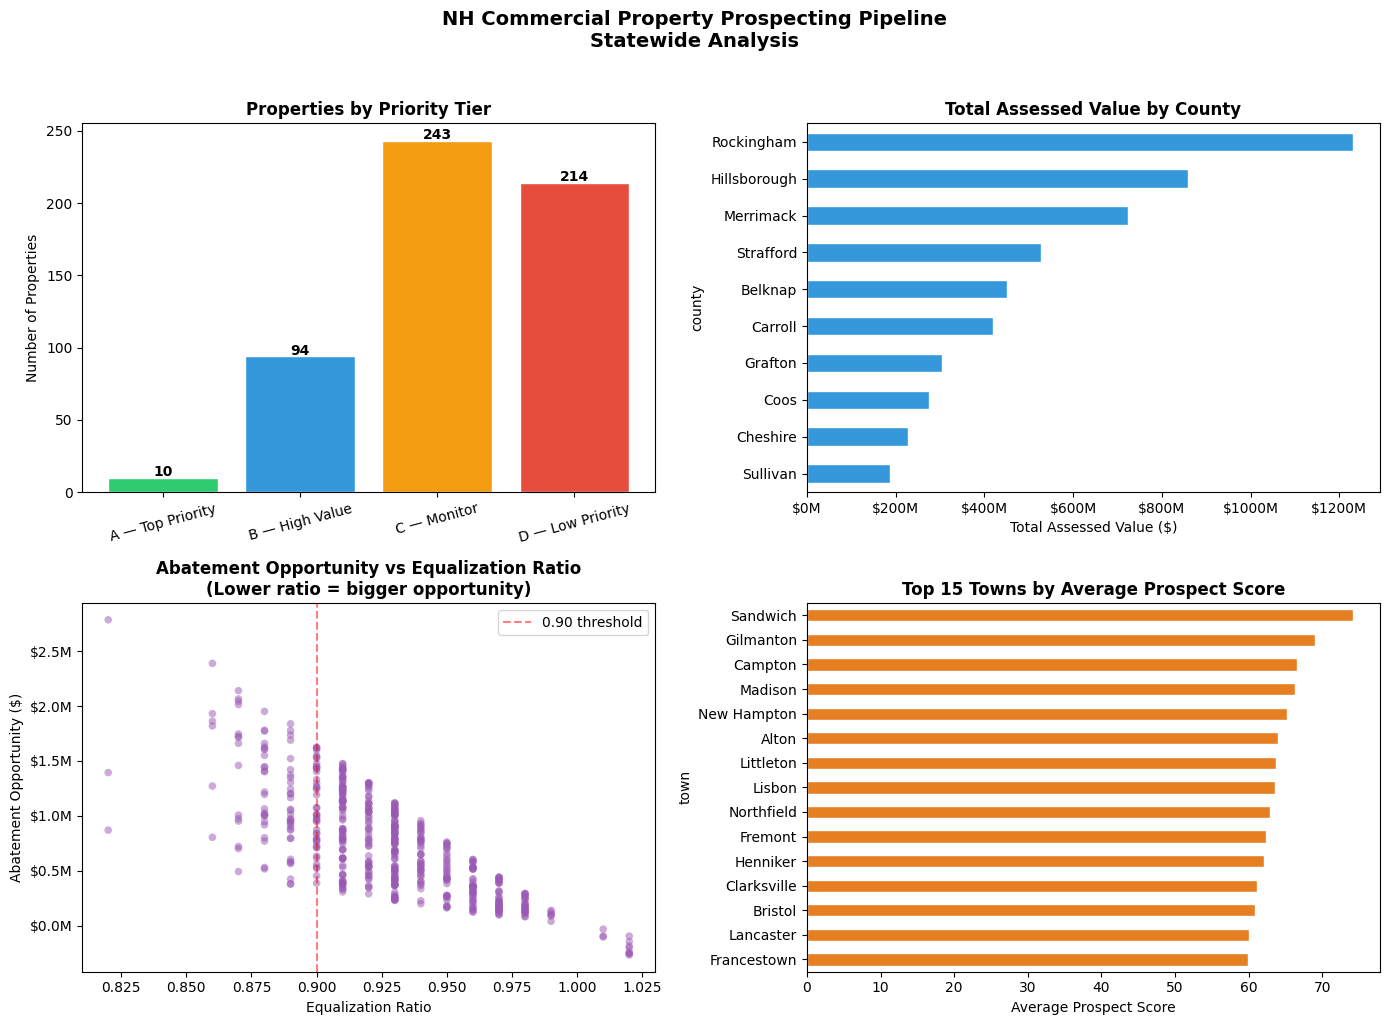

✅ Charts saved as prospecting_analysis.png


In [ ]:
# ── VISUALIZATIONS ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NH Commercial Property Prospecting Pipeline\nStatewide Analysis',
             fontsize=14, fontweight='bold', y=1.02)

# ── CHART 1: Properties by Priority Tier ────────────────────────
tier_order = ['A — Top Priority', 'B — High Value',
              'C — Monitor', 'D — Low Priority']
tier_colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
tier_counts = [df_results['priority_tier'].value_counts().get(t, 0)
               for t in tier_order]

axes[0,0].bar(tier_order, tier_counts, color=tier_colors, edgecolor='white')
axes[0,0].set_title('Properties by Priority Tier', fontweight='bold')
axes[0,0].set_ylabel('Number of Properties')
axes[0,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(tier_counts):
    axes[0,0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# ── CHART 2: Total Assessed Value by County ─────────────────────
county_val = df_results.groupby('county')['assessed_value'].sum().sort_values()
county_val.plot(kind='barh', ax=axes[0,1], color='#3498db', edgecolor='white')
axes[0,1].set_title('Total Assessed Value by County', fontweight='bold')
axes[0,1].set_xlabel('Total Assessed Value ($)')
axes[0,1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M')
)

# ── CHART 3: Abatement Opportunity by Equalization Ratio ────────
axes[1,0].scatter(
    df_results['eq_ratio'],
    df_results['abatement_opportunity'],
    alpha=0.5, color='#9b59b6', edgecolor='none', s=30
)
axes[1,0].set_title('Abatement Opportunity vs Equalization Ratio\n(Lower ratio = bigger opportunity)',
                     fontweight='bold')
axes[1,0].set_xlabel('Equalization Ratio')
axes[1,0].set_ylabel('Abatement Opportunity ($)')
axes[1,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M')
)
axes[1,0].axvline(x=0.90, color='red', linestyle='--',
                   alpha=0.5, label='0.90 threshold')
axes[1,0].legend()

# ── CHART 4: Top 15 Towns by Average Prospect Score ─────────────
top_towns = df_results.groupby('town')['prospect_score'].mean()\
            .sort_values(ascending=False).head(15)
top_towns.plot(kind='barh', ax=axes[1,1], color='#e67e22', edgecolor='white')
axes[1,1].set_title('Top 15 Towns by Average Prospect Score', fontweight='bold')
axes[1,1].set_xlabel('Average Prospect Score')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('prospecting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved as prospecting_analysis.png")